In [1]:
### imports
import os
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine, text
from dotenv import load_dotenv

In [2]:
### config
load_dotenv()

USER = os.getenv("DB_USER")
PASS = os.getenv("DB_PASS")
HOST = os.getenv("DB_HOST")
DB = os.getenv("DB")
PORT = os.getenv("DB_PORT")

#print(f"postgresql://{USER}:{PASS}@{HOST}:{PORT}/{DB}")

connection_string = f"postgresql://{USER}:{PASS}@{HOST}:{PORT}/{DB}"

engine = create_engine(connection_string)

In [3]:
### create some queries and run one
q_od = 'SELECT * FROM overdose_deaths'
q_TN_county = "SELECT * FROM fips_county WHERE state = 'TN'"
q_od_joined = """
    select c.county, od.year, od.overdose_deaths
    from overdose_deaths od
    join fips_county c 
    on c.fipscounty = od.fipscounty
    """

with engine.connect() as connection:
    od = pd.read_sql(text(q_od), con = connection) 
    TN_county = pd.read_sql(text(q_TN_county), con = connection)
    od_TN_county = pd.read_sql(text(q_od_joined), con = connection)

od_TN_county

,county,year,overdose_deaths
0,ANDERSON,2018,18
1,ANDERSON,2017,34
2,ANDERSON,2016,24
3,ANDERSON,2015,20
4,BEDFORD,2018,7
...,...,...,...
375,WILLIAMSON,2015,21
376,WILSON,2018,19
377,WILSON,2017,26
378,WILSON,2016,27


# 1 - 
Deaths over time. a. How has total overdose deaths changed over time? b. How have overdose deaths changed over time for Davidson and Shelby counties. c. Are there any counties in which overdose deaths are trending downward?

# Overdose Deaths in TN 2015-2018

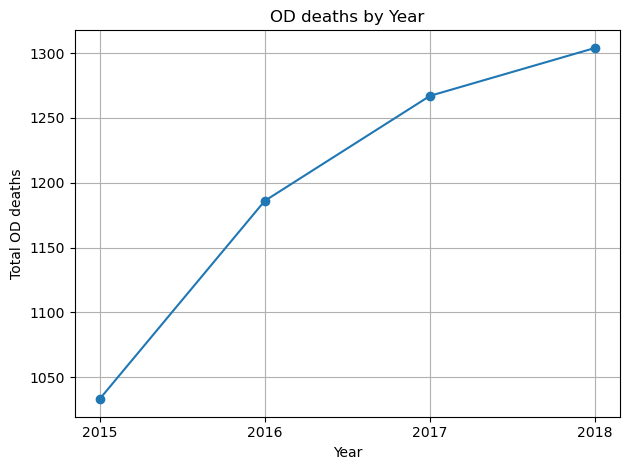

In [4]:
### plot OD deaths by year for TN
## get od deaths by year
od_TN_by_year = od_TN_county.groupby('year', as_index=False)['overdose_deaths'].sum()
od_TN_by_year
plt.figure()
plt.plot(od_TN_by_year['year'], od_TN_by_year['overdose_deaths'], marker='o')
#plt.bar(od_by_year['year'], od_by_year['overdose_deaths'])

plt.xlabel('Year')
plt.ylabel('Total OD deaths')
plt.title('OD deaths by Year')

## get unique year cause I dont like 2015.5
years = sorted(od_TN_by_year["year"].unique())
plt.xticks(years)

plt.grid()
plt.tight_layout()

plt.show()

In [5]:
### return sql for ONLY davidson and shelby counties
q = """
    select *
    from overdose_deaths od
    join fips_county c
    on c.fipscounty = od.fipscounty
    where c.county = 'DAVIDSON' or c.county = 'SHELBY'
    """

with engine.connect() as connection:
    davidson_shelby = pd.read_sql(text(q), con = connection) 

davidson_shelby

,overdose_deaths,year,fipscounty,county,state,fipscounty,fipsstate
0,135,2015,47157,SHELBY,TN,47157,47
1,150,2016,47157,SHELBY,TN,47157,47
2,159,2017,47157,SHELBY,TN,47157,47
3,123,2018,47157,SHELBY,TN,47157,47
4,127,2015,47037,DAVIDSON,TN,47037,47
5,178,2016,47037,DAVIDSON,TN,47037,47
6,184,2017,47037,DAVIDSON,TN,47037,47
7,200,2018,47037,DAVIDSON,TN,47037,47


In [6]:
### split up each county for graph
davidson = davidson_shelby[davidson_shelby["county"] == "DAVIDSON"]
shelby = davidson_shelby[davidson_shelby["county"] == "SHELBY"]

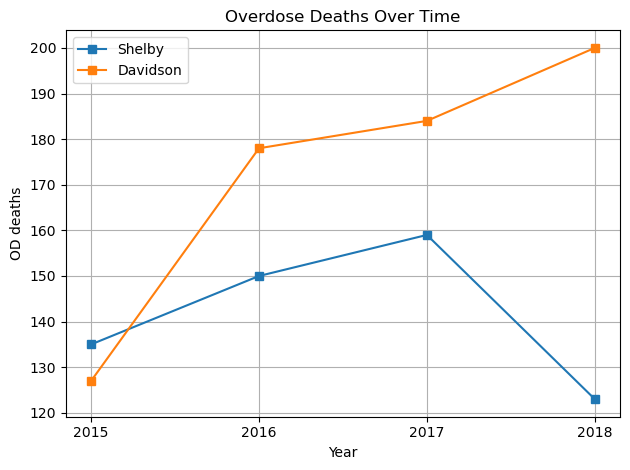

In [7]:
### plot both lines onto chart
plt.plot(shelby["year"], shelby["overdose_deaths"], marker="s", label="Shelby")
plt.plot(davidson["year"], davidson["overdose_deaths"], marker="s", label="Davidson")

## labels
plt.xlabel("Year")
plt.ylabel("OD deaths")
plt.title("Overdose Deaths Over Time")

## get unique year cause I dont like 2015.5
years = sorted(shelby["year"].unique())
plt.xticks(years)

## never see much diff when I add this but it's reassuring
plt.tight_layout()

## label the lines
plt.legend()
plt.grid()

plt.show()

# Overdose deaths by TN county

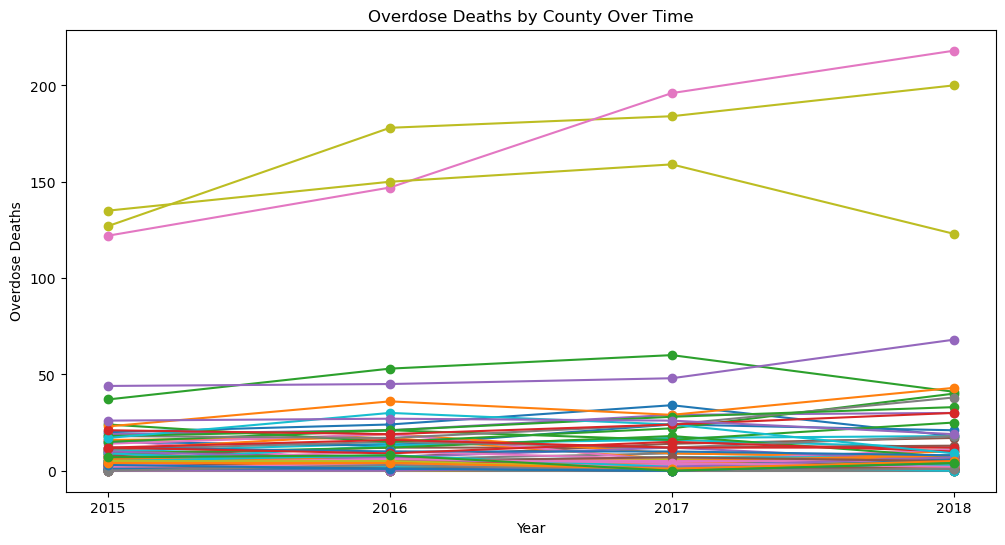

In [8]:
### make pivot from TN county data
pivot = od_TN_county.pivot(index="year", columns="county", values="overdose_deaths")

pivot = pivot.sort_index()

## make the plot
pivot.plot(marker="o", figsize=(12, 6), legend=False)

## details
plt.xlabel("Year")
plt.ylabel("Overdose Deaths")
plt.title("Overdose Deaths by County Over Time")
## too many counties for this chart
#plt.legend(bbox_to_anchor=(1, 1))
plt.xticks(pivot.index)

# print(pivot)

plt.show()

# Top 10 counties in Overdose Deaths

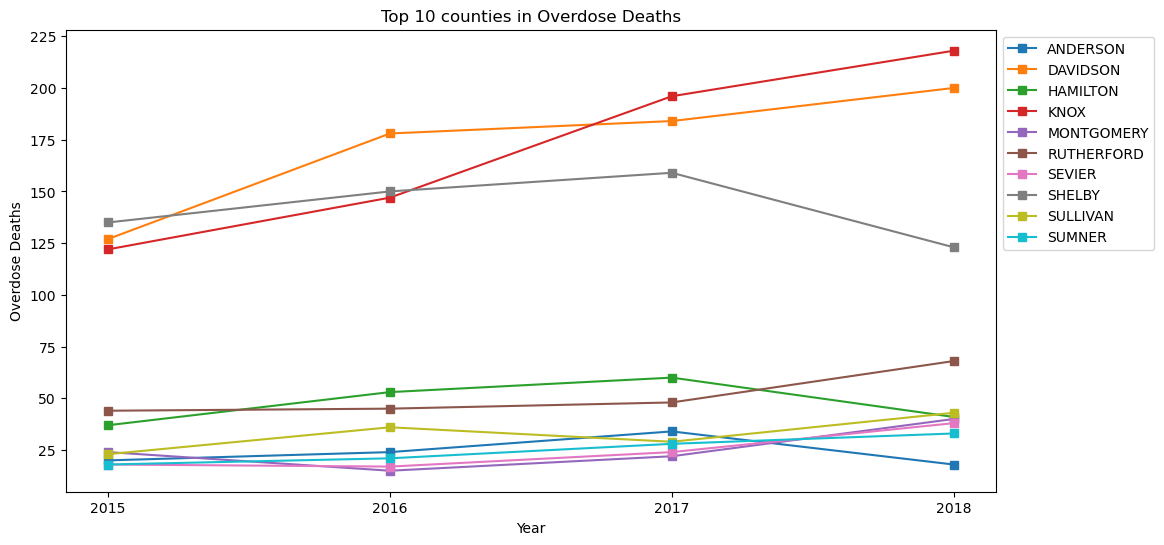

In [9]:
# find top 10 counties by peak overdose deaths
top10_counties = (
    od_TN_county.groupby("county")["overdose_deaths"]
    .max()
    .sort_values(ascending=False)
    .head(10)
    .index
)
#print(top10_counties)

df_TN_top10 = od_TN_county[od_TN_county["county"].isin(top10_counties)]

pivot = df_TN_top10.pivot(index="year", columns="county", values="overdose_deaths").sort_index()

pivot.plot(marker="s", figsize=(12,6))

plt.xlabel("Year")
plt.ylabel("Overdose Deaths")
plt.title("Top 10 counties in Overdose Deaths")
plt.xticks(pivot.index)
plt.legend(bbox_to_anchor=(1, 1), loc="upper left")

plt.show()

# ______________________________________________________________

# Top prescribers 
a. Where are the top 10 opioid prescribers located? b. Who is the top prescriber in each county? c. What proportion of opioids are prescribed by the top 10 prescribers? Top 50? Top 100?

In [13]:
### create some queries and run one
q_drug = "SELECT * FROM drug"
q_rx = "SELECT * FROM prescription"
q_prescriber = "SELECT * FROM prescriber"


with engine.connect() as connection:
    drug = pd.read_sql(text(q_drug), con = connection) 
    rx = pd.read_sql(text(q_rx), con = connection)
    prescriber = pd.read_sql(text(q_prescriber), con = connection)

prescriber

,npi,nppes_provider_last_org_name,nppes_provider_first_name,nppes_provider_mi,nppes_credentials,nppes_provider_gender,nppes_entity_code,nppes_provider_street1,nppes_provider_street2,nppes_provider_city,nppes_provider_zip5,nppes_provider_zip4,nppes_provider_state,nppes_provider_country,specialty_description,description_flag,medicare_prvdr_enroll_status
0,1.003000e+09,BLAKEMORE,ROSIE,K,FNP,F,I,TENNESSEE PRISON FOR WOMEN,3881 STEWARTS LANE,NASHVILLE,37243,0001,TN,US,Nurse Practitioner,S,N
1,1.003012e+09,CUDZILO,COREY,None,M.D.,M,I,2240 SUTHERLAND AVE,SUITE 103,KNOXVILLE,37919,2333,TN,US,Pulmonary Disease,S,E
2,1.003013e+09,GRABENSTEIN,WILLIAM,P,M.D.,M,I,1822 MEMORIAL DR,None,CLARKSVILLE,37043,4605,TN,US,Family Practice,S,E
3,1.003014e+09,OTTO,ROBERT,J,M.D.,M,I,2400 PATTERSON STREET SUITE 100,None,NASHVILLE,37203,2786,TN,US,Orthopedic Surgery,S,E
4,1.003018e+09,TODD,JOSHUA,W,M.D.,M,I,1819 W CLINCH AVE,SUITE 108,KNOXVILLE,37916,2435,TN,US,Cardiology,S,E
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25045,1.992986e+09,BECK,ROBERT,L,M.D,M,I,2400 PATTERSON ST,SUITE 400,NASHVILLE,37203,1562,TN,US,Internal Medicine,S,E
25046,1.992994e+09,CHAKRABORTY,KANISHKA,None,M.D,M,I,1 PROFESSIONAL PARK DR,SUITE 21,JOHNSON CITY,37604,6587,TN,US,Internal Medicine,S,E
25047,1.992996e+09,GILES,WESLEY,H,MD,M,I,979 E 3RD ST STE 300,None,CHATTANOOGA,37403,2187,TN,US,Emergency Medicine,S,E
25048,1.992998e+09,DRAPER,DAVID,G,DDS,M,I,202 SHIPLEY STREET,None,COOKEVILLE,38501,None,TN,US,Dentist,T,N
